# Feedforward Neural Networks (FNNs)
This notebook provides some examples of Feedforward Neural Networks (FNNs). 

In [19]:
# Author: Roberto Doriguzzi-Corin
# Project: Course on Network Intrusion and Anomaly Detection with Machine Learning
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, GlobalMaxPool2D, Flatten, Dense, Input
from tensorflow.keras.utils import plot_model

# Logistic regression
Logistic regression for binary classification.

Model: "log_reg"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_37 (Dense)            (None, 1)                 22        
                                                                 
Total params: 22
Trainable params: 22
Non-trainable params: 0
_________________________________________________________________
None


python(9699) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(9700) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


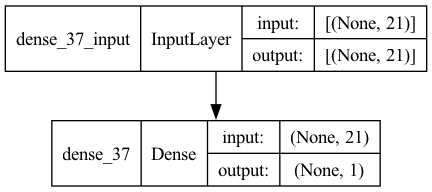

In [21]:
# Define a logistic regression model
model = Sequential(name="log_reg", layers=[
    Dense(1, input_shape=(21,), activation='sigmoid'),
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Train the model and pass the TensorBoard callback
print (model.summary())

# Visualize the model architecture
plot_model(model, to_file='log_reg_plot.png', show_shapes=True, show_layer_names=True)

# Multi-Layer Perceptron (MLP)
MLP for binary classification.

Model: "MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_38 (Dense)            (None, 64)                1408      
                                                                 
 dense_39 (Dense)            (None, 32)                2080      
                                                                 
 dense_40 (Dense)            (None, 1)                 33        
                                                                 
Total params: 3,521
Trainable params: 3,521
Non-trainable params: 0
_________________________________________________________________
None


python(9706) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(9707) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


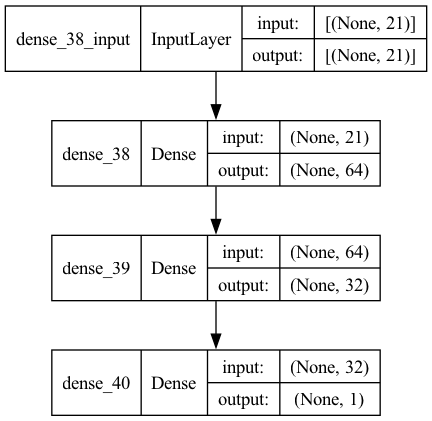

In [22]:
# Define a simple neural network model
model = Sequential(name="MLP", layers=[
    Dense(64, input_shape=(21,), activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Train the model and pass the TensorBoard callback
print (model.summary())

# Visualize the model architecture
plot_model(model, to_file='mlp_plot.png', show_shapes=True, show_layer_names=True)

# Convolutional Neural Network (CNN)
CNN fir binary classification

Model: "CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 8, 19, 64)         640       
                                                                 
 global_max_pooling2d_2 (Glo  (None, 64)               0         
 balMaxPooling2D)                                                
                                                                 
 flatten_2 (Flatten)         (None, 64)                0         
                                                                 
 dense_41 (Dense)            (None, 32)                2080      
                                                                 
 dense_42 (Dense)            (None, 1)                 33        
                                                                 
Total params: 2,753
Trainable params: 2,753
Non-trainable params: 0
_____________________________________________________________

python(9711) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(9712) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


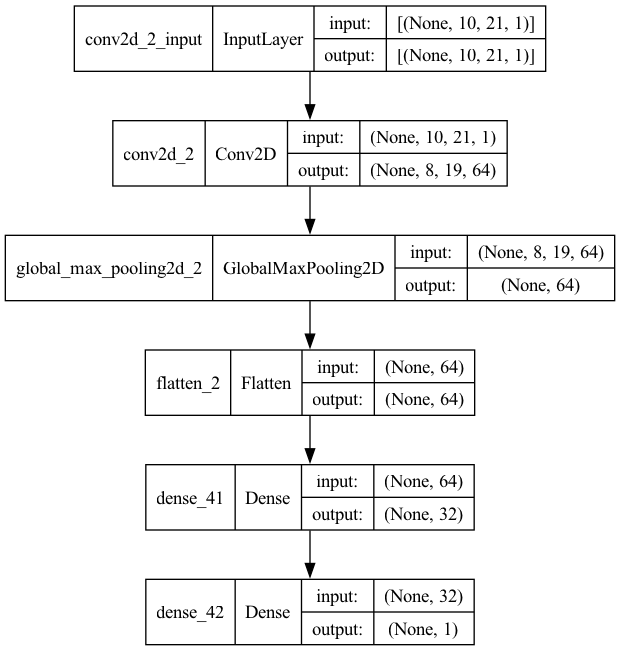

In [23]:
# Define the CNN model
model = Sequential(name="CNN", layers=[
    Conv2D(64, (3, 3), activation='relu', input_shape=(10, 21, 1)),
    GlobalMaxPool2D(),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer with 10 classes (for Fashion MNIST)
])

# Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
print (model.summary())

# Plot the model architecture and save it to a file
plot_model(model, to_file='cnn_model.png', show_shapes=True, show_layer_names=True)


# Autoencoder
Autoencoder for anomaly detection.

Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 enc_input (InputLayer)      [(None, 21)]              0         
                                                                 
 enc_hidden (Dense)          (None, 20)                440       
                                                                 
 enc_output (Dense)          (None, 10)                210       
                                                                 
 decoder (Functional)        (None, 21)                661       
                                                                 
Total params: 1,311
Trainable params: 1,311
Non-trainable params: 0
_________________________________________________________________
None


python(9716) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(9717) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


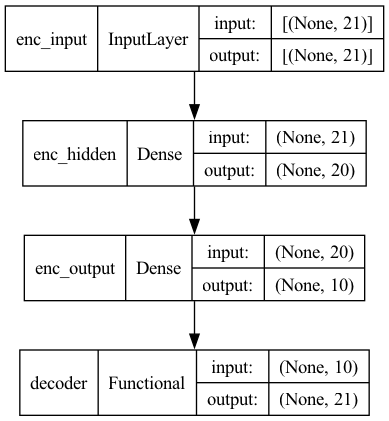

In [24]:
# Define the input shape
input_shape = (21,)  # Assuming an input vector of 21 features

# Define the encoder part
encoder_input = Input(shape=input_shape,name='enc_input')
encoded = Dense(20, activation='relu',name='enc_hidden')(encoder_input)  # Encoder with a single hidden layer
encoder_output = Dense(10, activation='relu',name='enc_output')(encoded)  # Latent space representation

# Define the decoder part
decoder_input = Input(shape=(10,),name='dec_input')
decoded = Dense(20, activation='relu',name='dec_hidden')(decoder_input)  # Decoder with a single hidden layer
decoded_output = Dense(21, activation='linear',name='dec_output')(decoded)  # Output layer with sigmoid activation

# Create the encoder and decoder models
encoder = Model(encoder_input, encoder_output, name='encoder')
decoder = Model(decoder_input, decoded_output, name='decoder')

# Create the autoencoder model
autoencoder = Model(encoder_input, decoder(encoder_output), name='autoencoder')

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='MSE')
print(autoencoder.summary())

# Plot the architecture of the autoencoder and save it to a file
plot_model(autoencoder, to_file='autoencoder_model.png', show_shapes=True, show_layer_names=True)